# Phase 1 — Tabular data: pattern discovery in wide/pivoted tables (Solution)

**Mục tiêu:** pivot `long → wide` để thấy pattern theo hai khóa (ví dụ `continent` × `year`), rồi heatmap / clustermap để *sắp xếp lại hàng/cột* theo similarity.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

from pathlib import Path

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError(
        "Cannot locate data/gapminder.csv from current working directory"
    )

root = resolve_repo_root()


sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "gapminder.csv")
df.head()


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## 1) Pivot: mean lifeExp theo continent × year


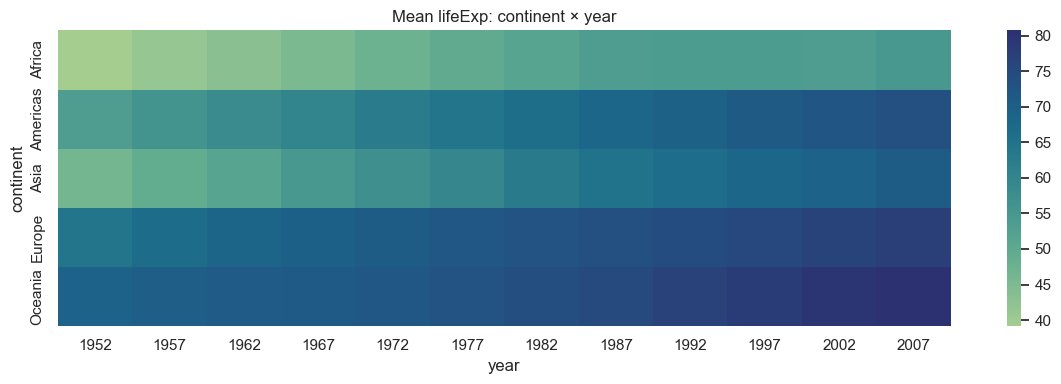

In [2]:
p = (
    df.groupby(["continent", "year"], as_index=False)["lifeExp"]
    .mean()
    .pivot(index="continent", columns="year", values="lifeExp")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(p, cmap="crest", ax=ax)
ax.set_title("Mean lifeExp: continent × year")
plt.tight_layout()
plt.show()


## 2) Wide feature table theo country (2007) + clustermap


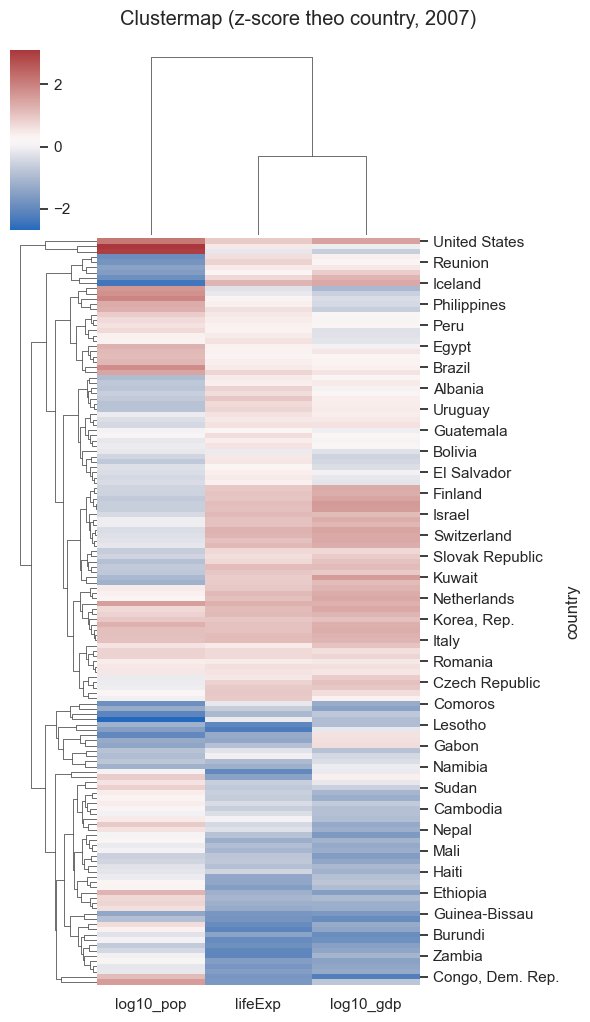

In [3]:
d2007 = df[df["year"] == 2007].copy()
feat = d2007.set_index("country")[["lifeExp", "gdpPercap", "pop"]].copy()
feat["log10_gdp"] = np.log10(feat["gdpPercap"].to_numpy(dtype=float))
feat["log10_pop"] = np.log10(np.maximum(feat["pop"].to_numpy(dtype=float), 1.0))
feat = feat[["lifeExp", "log10_gdp", "log10_pop"]]

z_feat = pd.DataFrame(zscore(feat.to_numpy(dtype=float)), index=feat.index, columns=feat.columns)

cg = sns.clustermap(
    z_feat,
    cmap="vlag",
    figsize=(6, 10),
    row_cluster=True,
    col_cluster=True,
)
cg.fig.suptitle("Clustermap (z-score theo country, 2007)", y=1.02)
plt.show()


## 3) Sort/reorder insight

Clustermap đã reorder rows; heatmap thường cần **sort có chủ đích** (theo metric) khi mục tiêu là ranking — khác clustering.


In [4]:
continent_year = (
    df.groupby(["continent", "year"], as_index=False)["lifeExp"]
    .mean()
    .sort_values(["year", "lifeExp"])
)
continent_year.tail(12)


,continent,year,lifeExp
45,Europe,1997,75.505167
57,Oceania,1997,78.190000
10,Africa,2002,53.325231
34,Asia,2002,69.233879
22,Americas,2002,72.422040
46,Europe,2002,76.700600
58,Oceania,2002,79.740000
11,Africa,2007,54.806038
35,Asia,2007,70.728485
23,Americas,2007,73.608120


## Reflection

- Heatmap sau pivot khác “ảnh của raw table” ở điểm nào?
- Clustermap reorder có phải “ground truth causal” không? Vì sao?
- Khi nào nên sort theo một metric có định nghĩa thay vì cluster.


## Legacy add-on (tach tu `legacy_chapter_aligned/solution.executed.ipynb`)

Phan bo sung nay duoc ghep lai tu notebook cu de giu noi dung theo giao trinh, nhung da map vao track tabular hien tai.

### Imported section: ## 2) Color scales
Mục tiêu: dùng sequential/diverging đúng ngữ cảnh.

## 2) Color scales
Mục tiêu: dùng sequential/diverging đúng ngữ cảnh.

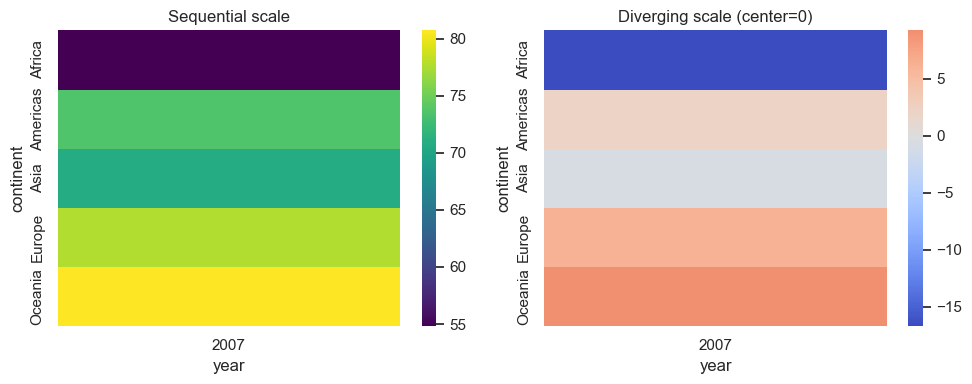

In [5]:
pivot = df[df["year"]==2007].pivot_table(index="continent", columns="year", values="lifeExp", aggfunc="mean")

fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.heatmap(pivot, cmap="viridis", ax=axes[0], cbar=True)
axes[0].set_title("Sequential scale")

centered = pivot - pivot.mean().mean()
sns.heatmap(centered, cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("Diverging scale (center=0)")
plt.tight_layout(); plt.show()